In [42]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle (1).json


{'kaggle (1).json': b'{"username":"sarveyasha","key":"858a2ad23f07dcdd99fbb45efa7a5edc"}'}

In [43]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [44]:
!kaggle datasets download -d pranavraikokte/covid19-image-dataset

Dataset URL: https://www.kaggle.com/datasets/pranavraikokte/covid19-image-dataset
License(s): CC-BY-SA-4.0
covid19-image-dataset.zip: Skipping, found more recently modified local copy (use --force to force download)


In [45]:
!unzip covid19-image-dataset.zip

Archive:  covid19-image-dataset.zip
replace Covid19-dataset/test/Covid/0100.jpeg? [y]es, [n]o, [A]ll, [N]one, [r]ename: All
  inflating: Covid19-dataset/test/Covid/0100.jpeg  
  inflating: Covid19-dataset/test/Covid/0102.jpeg  
  inflating: Covid19-dataset/test/Covid/0105.png  
  inflating: Covid19-dataset/test/Covid/0106.jpeg  
  inflating: Covid19-dataset/test/Covid/0108.jpeg  
  inflating: Covid19-dataset/test/Covid/0111.jpg  
  inflating: Covid19-dataset/test/Covid/0112.jpg  
  inflating: Covid19-dataset/test/Covid/0113.jpg  
  inflating: Covid19-dataset/test/Covid/0115.jpeg  
  inflating: Covid19-dataset/test/Covid/0118.jpeg  
  inflating: Covid19-dataset/test/Covid/0119.jpeg  
  inflating: Covid19-dataset/test/Covid/0120.jpg  
  inflating: Covid19-dataset/test/Covid/094.png  
  inflating: Covid19-dataset/test/Covid/096.png  
  inflating: Covid19-dataset/test/Covid/098.jpeg  
  inflating: Covid19-dataset/test/Covid/COVID-00003b.jpg  
  inflating: Covid19-dataset/test/Covid/COVID-0

In [46]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras.layers import Flatten, Dense, Dropout
from tensorflow.keras.utils import to_categorical

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score

In [47]:
data = []
labels = []

classes = ['Covid', 'Normal', 'Viral Pneumonia']

for category in classes:
    path = f'Covid19-dataset/train/{category}'

    for img in os.listdir(path):
        img_path = os.path.join(path, img)

        image = cv2.imread(img_path)
        image = cv2.resize(image, (128, 128))

        data.append(image)
        labels.append(category)

In [48]:
X = np.array(data)
y = np.array(labels)

In [49]:
X = X / 255.0

In [50]:
encoder = LabelEncoder()

y_encoded = encoder.fit_transform(y)

y_categorical = to_categorical(y_encoded)

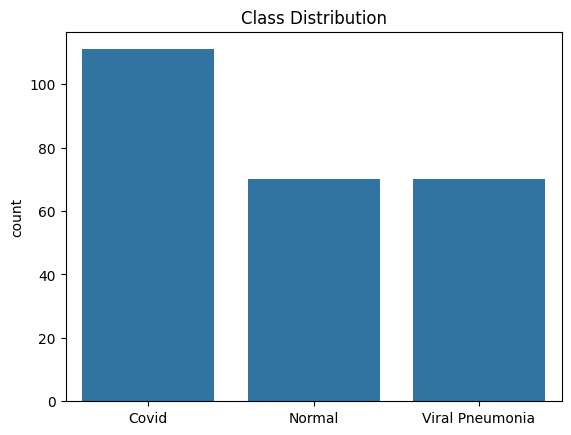

In [51]:
import seaborn as sns

sns.countplot(x=y)
plt.title("Class Distribution")
plt.show()

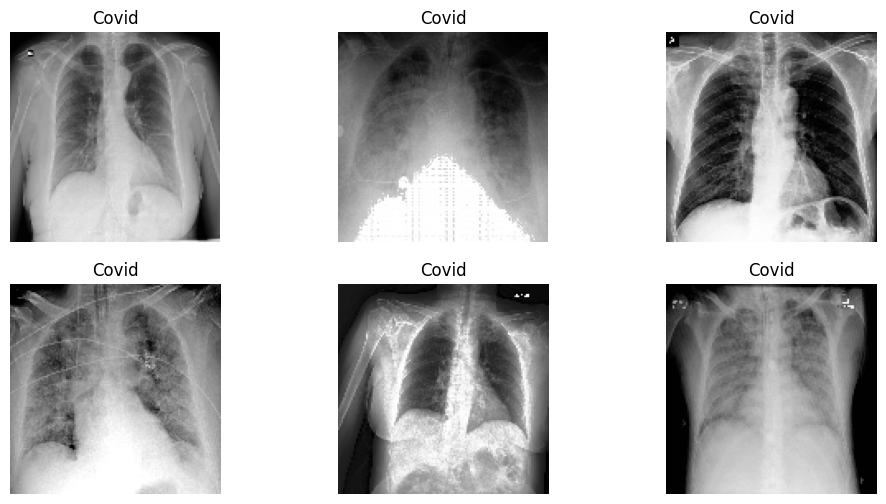

In [52]:
plt.figure(figsize=(12,6))

for i in range(6):
    plt.subplot(2,3,i+1)
    plt.imshow(X[i])
    plt.title(labels[i])
    plt.axis('off')

plt.show()

In [53]:
model = Sequential()

model.add(Conv2D(32, (3,3), activation='relu',
                 input_shape=(128,128,3)))

model.add(MaxPooling2D(2,2))

model.add(Conv2D(64, (3,3), activation='relu'))
model.add(MaxPooling2D(2,2))

model.add(Flatten())

model.add(Dense(128, activation='relu'))

model.add(Dropout(0.5))

model.add(Dense(3, activation='softmax'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [54]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [55]:
X_train, X_test, y_train, y_test = train_test_split(X, y_categorical, test_size=0.2, random_state=42)

history = model.fit(
    X_train,
    y_train,
    epochs=10,
    validation_split=0.2,
    batch_size=32
)

Epoch 1/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 6s 829ms/step - accuracy: 0.3688 - loss: 3.7082 - val_accuracy: 0.3250 - val_loss: 1.2211
Epoch 2/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 5s 866ms/step - accuracy: 0.4125 - loss: 1.1554 - val_accuracy: 0.6500 - val_loss: 1.0319
Epoch 3/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 4s 742ms/step - accuracy: 0.6625 - loss: 0.9274 - val_accuracy: 0.7500 - val_loss: 0.8386
Epoch 4/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 4s 714ms/step - accuracy: 0.8438 - loss: 0.6951 - val_accuracy: 0.7500 - val_loss: 0.5521
Epoch 5/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 5s 1s/step - accuracy: 0.9000 - loss: 0.3883 - val_accuracy: 0.8500 - val_loss: 0.4270
Epoch 6/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 4s 727ms/step - accuracy: 0.9187 - loss: 0.2741 - val_accuracy: 0.8750 - val_loss: 0.3246
Epoch 7/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 4s 748ms/step - accuracy: 0.9250 - loss: 0.1785 - val_accuracy: 0.8750 - val_loss: 0.4171
Epoch 8/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 5s 1s/step - accuracy: 0.9500 - loss: 0.1209 - val_accuracy: 0.8500 - val_loss: 0.444

In [56]:
loss, accuracy = model.evaluate(X_test, y_test)

print("Accuracy:", accuracy)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 141ms/step - accuracy: 0.9804 - loss: 0.0529
Accuracy: 0.9803921580314636


In [57]:
predictions = model.predict(X_test)

predicted_labels = np.argmax(predictions, axis=1)
true_labels = np.argmax(y_test, axis=1)

cm = confusion_matrix(true_labels, predicted_labels)

print(cm)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 174ms/step
[[23  0  0]
 [ 0 13  1]
 [ 0  0 14]]


In [58]:
print(classification_report(
    true_labels,
    predicted_labels
))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        23
           1       1.00      0.93      0.96        14
           2       0.93      1.00      0.97        14

    accuracy                           0.98        51
   macro avg       0.98      0.98      0.98        51
weighted avg       0.98      0.98      0.98        51



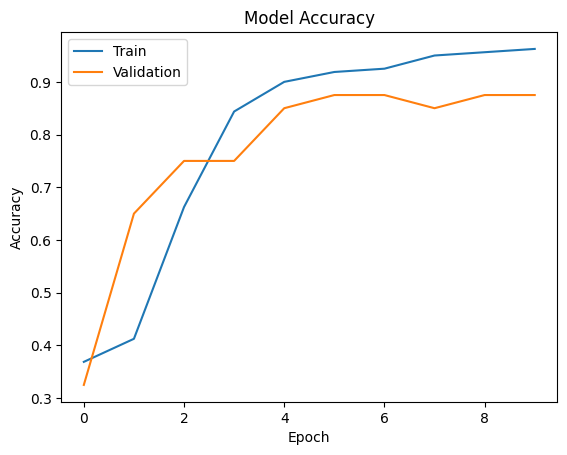

In [59]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')

plt.legend(['Train', 'Validation'])

plt.show()

In [60]:
from tensorflow.keras.applications import VGG16

In [61]:
base_model = VGG16(
    weights='imagenet',
    include_top=False,
    input_shape=(128,128,3)
)

In [62]:
for layer in base_model.layers:
    layer.trainable = False

In [63]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Flatten, Dense

vgg_model = Sequential()

vgg_model.add(base_model)
vgg_model.add(Flatten())
vgg_model.add(Dense(128, activation='relu'))
vgg_model.add(Dense(3, activation='softmax'))

In [64]:
vgg_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [41]:
vgg_history = vgg_model.fit(
    X_train,
    y_train,
    epochs=5,
    validation_split=0.2
)

Epoch 1/5
5/5 ━━━━━━━━━━━━━━━━━━━━ 55s 11s/step - accuracy: 0.9750 - loss: 0.0962 - val_accuracy: 0.8750 - val_loss: 0.3696
Epoch 2/5
5/5 ━━━━━━━━━━━━━━━━━━━━ 35s 7s/step - accuracy: 0.9937 - loss: 0.0707 - val_accuracy: 0.8500 - val_loss: 0.3878
Epoch 3/5
5/5 ━━━━━━━━━━━━━━━━━━━━ 34s 7s/step - accuracy: 0.9937 - loss: 0.0587 - val_accuracy: 0.9000 - val_loss: 0.3524
Epoch 4/5
5/5 ━━━━━━━━━━━━━━━━━━━━ 40s 7s/step - accuracy: 0.9937 - loss: 0.0448 - val_accuracy: 0.9000 - val_loss: 0.3346
Epoch 5/5
5/5 ━━━━━━━━━━━━━━━━━━━━ 37s 8s/step - accuracy: 1.0000 - loss: 0.0373 - val_accuracy: 0.9000 - val_loss: 0.3318
Epoch 1/5
5/5 ━━━━━━━━━━━━━━━━━━━━ 39s 8s/step - accuracy: 0.4625 - loss: 1.5931 - val_accuracy: 0.4750 - val_loss: 1.0285
Epoch 2/5
5/5 ━━━━━━━━━━━━━━━━━━━━ 38s 8s/step - accuracy: 0.7500 - loss: 0.5368 - val_accuracy: 0.8500 - val_loss: 0.3989
Epoch 3/5
2/5 ━━━━━━━━━━━━━━━━━━━━ 18s 6s/step - accuracy: 0.9141 - loss: 0.2669

In [65]:
from tensorflow.keras.applications import ResNet50

In [66]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [67]:
datagen = ImageDataGenerator(
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

In [68]:
datagen.fit(X_train)

In [69]:
from tensorflow.keras.callbacks import EarlyStopping

In [70]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3
)

In [71]:
model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=20,
    callbacks=[early_stop]
)

Epoch 1/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 5s 854ms/step - accuracy: 0.9750 - loss: 0.0743 - val_accuracy: 0.8500 - val_loss: 0.4797
Epoch 2/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 4s 738ms/step - accuracy: 0.9563 - loss: 0.0857 - val_accuracy: 0.8750 - val_loss: 0.4741
Epoch 3/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 4s 731ms/step - accuracy: 0.9875 - loss: 0.0589 - val_accuracy: 0.8750 - val_loss: 0.5398
Epoch 4/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 5s 945ms/step - accuracy: 0.9688 - loss: 0.0636 - val_accuracy: 0.8500 - val_loss: 0.5951
Epoch 5/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 4s 714ms/step - accuracy: 0.9937 - loss: 0.0394 - val_accuracy: 0.8750 - val_loss: 0.4670
Epoch 6/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 6s 831ms/step - accuracy: 0.9875 - loss: 0.0446 - val_accuracy: 0.8500 - val_loss: 0.5241
Epoch 7/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 4s 803ms/step - accuracy: 0.9875 - loss: 0.0332 - val_accuracy: 0.8500 - val_loss: 0.6152
Epoch 8/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 4s 740ms/step - accuracy: 0.9937 - loss: 0.0234 - val_accuracy: 0.8500 - val_loss:

In [72]:
from sklearn.utils.class_weight import compute_class_weight

In [73]:
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_encoded),
    y=y_encoded
)

In [74]:
from sklearn.metrics import roc_auc_score

roc_auc_score(y_test, predictions, multi_class='ovr')

np.float64(0.9993564993564994)

In [75]:
model.save("covid_model.h5")

In [76]:
from google.colab import files
files.download("covid_model.h5")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [77]:
%%writefile app.py

import streamlit as st
import numpy as np
import cv2

from tensorflow.keras.models import load_model

model = load_model('covid_model.h5')

classes = ['Covid', 'Normal', 'Viral Pneumonia']

st.title("COVID Detection from Chest X-Ray")

uploaded_file = st.file_uploader(
    "Upload X-Ray Image",
    type=['jpg','png','jpeg']
)

if uploaded_file is not None:

    file_bytes = np.asarray(
        bytearray(uploaded_file.read()),
        dtype=np.uint8
    )

    image = cv2.imdecode(file_bytes, 1)

    image = cv2.resize(image, (128,128))

    image = image / 255.0

    image = np.expand_dims(image, axis=0)

    prediction = model.predict(image)

    predicted_class = classes[np.argmax(prediction)]

    st.image(uploaded_file)

    st.success(f"Prediction: {predicted_class}")

Overwriting app.py


In [78]:
!ls


 app.py			     covid_model.h5     requirements.txt
 Covid19-dataset	    'kaggle (1).json'   sample_data
 covid19-image-dataset.zip   kaggle.json


In [79]:
%%writefile requirements.txt

tensorflow
streamlit
numpy
opencv-python-headless

Overwriting requirements.txt


In [80]:
from google.colab import files

files.download('app.py')
files.download('requirements.txt')
files.download('covid_model.h5')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>